# DMart Product Data Analysis

This notebook contains analysis of the DMart product dataset using:

- Pandas
- NumPy
- Matplotlib

The analysis covers basic data exploration, filtering, sorting, feature engineering, and group-by analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Dataset

In [3]:
df = pd.read_csv("dmart.csv")
df.head()

,Name,Brand,Price,Discounted Price,Category,Sub-Category,Quantity,Description,BreadCrumbs
0,Premia Badam (Almonds),Premia,451.0,329.0,Grocery,Grocery/Dry Fruits,500 gm,India,Grocery > Grocery/Dry Fruits
1,Premia Badam (Almonds),Premia,109.0,85.0,Grocery,Grocery/Dry Fruits,100 gm,India,Grocery > Grocery/Dry Fruits
2,Premia Badam (Almonds),Premia,202.0,175.0,Grocery,Grocery/Dry Fruits,200 gm,India,Grocery > Grocery/Dry Fruits
3,Nutraj California Almonds (Badam),Nutraj,599.0,349.0,Grocery,Dry Fruits,500 gm,USA,Grocery > Dry Fruits
4,Nutraj California Almonds (Badam),Nutraj,1549.0,659.0,Grocery,Dry Fruits,1 kg,USA,Grocery > Dry Fruits


## 2. Basic Analysis

In this section, we will understand the basic structure and quality of the dataset.

In [4]:
# First 10 rows
head = df.head(10)
print(head)

# Last 10 rows
tail = df.tail(10)
print(tail)

# Shape of dataset
shape = df.shape
print("Shape:", shape)

# Column names
columns = df.columns
print("Columns:", columns)

# Data types
data_types = df.dtypes
print(data_types)

# Missing values
missing_val = df.isnull().sum()
print("Missing Values:")
print(missing_val)

# Duplicate values
duplicate_val = df.duplicated()
print("Duplicate Rows:")
print(duplicate_val)

# Unique brands
unique_brand = df["Brand"].unique()
print("Unique Brands:")
print(unique_brand)

# Unique categories
unique_cat = df["Category"].unique()
print("Unique Categories:")
print(unique_cat)

# Product count
prod_count = df["Product"].value_counts()
print("Product Count:")
print(prod_count)

                                Name   Brand   Price  Discounted Price  \
0             Premia Badam (Almonds)  Premia   451.0             329.0   
1             Premia Badam (Almonds)  Premia   109.0              85.0   
2             Premia Badam (Almonds)  Premia   202.0             175.0   
3  Nutraj California Almonds (Badam)  Nutraj   599.0             349.0   
4  Nutraj California Almonds (Badam)  Nutraj  1549.0             659.0   
5                          Chana Dal     NaN    49.0              42.0   
6                          Chana Dal     NaN    96.0              80.0   
7                        Rajma White     NaN   112.0             102.0   
8                 Rajma Kashmiri Red     NaN   101.0              81.0   
9                 Premia Mamra Badam  Premia   634.0             488.0   

  Category        Sub-Category Quantity Description  \
0  Grocery  Grocery/Dry Fruits   500 gm       India   
1  Grocery  Grocery/Dry Fruits   100 gm       India   
2  Grocery  Grocery/

KeyError: 'Product'

## 3. Filtering Data
 Helps us find specific products based on brand, price, category, discount, and quantity.

In [5]:
# Products from Tata
brand_prod = df.query("Brand == 'Tata'")
print("Tata Products:")
print(brand_prod)

# Products costing more than 500
costly = df.query("Price > 500")
print("Products Above ₹500:")
print(costly)

# Products costing less than 100
cheap = df.query("Price < 100")
print("Products Below ₹100:")
print(cheap)

# Calculate savings
df["Savings"] = df["Price"] - df["Discounted Price"]

# Products with discount
discount = df[df["Savings"] > 0]

# Products without discount
no_discount = df[df["Savings"] == 0]

print("Products With Discount:")
print(discount)

print("Products Without Discount:")
print(no_discount)

# Products in Pulses sub-category
find_prod = df[df["Sub-Category"] == "Pulses"]
print("Pulses Products:")
print(find_prod)

# Find a specific product
show_prod = df[df["Name"] == "Premia Badam (Almonds)"]
print("Premia Badam:")
print(show_prod)

# Products whose quantity contains kg
heavy_prod = df[df["Quantity"].str.contains("kg", na=False)]
print("Products With KG Quantity:")
print(heavy_prod)

Tata Products:
                            Name Brand  Price  Discounted Price Category  \
10        Tata Sampann Chana Dal  Tata   64.0              49.0  Grocery   
11        Tata Sampann Chana Dal  Tata  125.0             112.0  Grocery   
34        Tata Sampann Moong Dal  Tata  175.0             148.0  Grocery   
35        Tata Sampann Moong Dal  Tata   88.0              79.0  Grocery   
148      Tata Sampann Masoor Dal  Tata   86.0              72.0  Grocery   
149      Tata Sampann Masoor Dal  Tata  170.0             145.0  Grocery   
843                    Tata Salt  Tata   28.0              25.0  Grocery   
845               Tata Salt Lite  Tata   50.0              45.0  Grocery   
846  Tata Rock Salt Powder Pouch  Tata  120.0              95.0  Grocery   
847  Tata Rock Salt Powder Pouch  Tata   65.0              50.0  Grocery   
850   Tata SuperLite Salt : 1 kg  Tata   60.0              49.0  Grocery   

               Sub-Category Quantity  \
10                     Dals   50

## 4. Sorting

Sorting allows us to identify the cheapest, most expensive, and highly discounted products.

In [6]:
# Price in ascending order
asc_price = df["Price"].sort_values(ascending=True)
print("Prices in Ascending Order:")
print(asc_price)

# Discounted price in descending order
discounted_des_price = df["Discounted Price"].sort_values(ascending=False)
print("Discounted Prices in Descending Order:")
print(discounted_des_price)

# 20 most expensive products
expensive_prod = (
    df.sort_values(by="Price", ascending=False)["Name"]
    .head(20)
)

print("20 Most Expensive Products:")
print(expensive_prod)

# Cheapest product
cheap_prod = (
    df.sort_values(by="Price", ascending=True)["Name"]
    .iloc[0]
)

print("Cheapest Product:", cheap_prod)

# Product with lowest discounted price
disc_prod = (
    df.sort_values(by="Discounted Price", ascending=True)["Name"]
    .iloc[0]
)

print("Lowest Discounted Price Product:", disc_prod)

Prices in Ascending Order:
2230        0.0
1344        5.0
2377       10.0
2364       10.0
1380       10.0
         ...   
413      4099.0
410      4500.0
2934     5300.0
406      5500.0
2796    10990.0
Name: Price, Length: 2980, dtype: float64
Discounted Prices in Descending Order:
2796    7999.0
410     3225.0
2919    2999.0
399     2799.0
389     2799.0
         ...  
1344       5.0
2191       1.0
2192       1.0
2193       1.0
2230       0.0
Name: Discounted Price, Length: 2980, dtype: float64
20 Most Expensive Products:
2796          Philips UV-C Disinfection System
406               Borges Extra Light Olive Oil
2934              Wonderchef Nutri-Blend Black
410                       Figaro Olive Oil Tin
413                  Leonardo Olive Pomace Oil
399           RRO Primio Refined Groundnut Oil
2919         Eureka Super Clean Vacuum Cleaner
390               Gulab Filtered Groundnut Oil
364               Godrej Refined Sunflower Oil
391              Guinea Filtered Groundnut Oil


## 5. Adding New Columns

Here we create new columns to calculate:

- Discount Amount
- Discount Percentage
- Savings
- Savings Category

In [7]:
# Discount amount
df["Disc_Amt"] = df["Price"] - df["Discounted Price"]

print("Discount Amount:")
print(df["Disc_Amt"])

# Discount percentage
df["Dist_Per"] = (
    (df["Price"] - df["Discounted Price"])
    / df["Price"]
) * 100

print("Discount Percentage:")
print(df["Dist_Per"])

# Savings
df["Savings"] = df["Price"] - df["Discounted Price"]

# Savings category
df["Savings_Cat"] = np.where(
    df["Savings"] >= 500,
    "High",
    np.where(
        df["Savings"] <= 50,
        "Medium",
        "Low"
    )
)

print("Savings Category:")
print(df["Savings_Cat"])

Discount Amount:
0       122.0
1        24.0
2        27.0
3       250.0
4       890.0
        ...  
2975     24.0
2976    116.0
2977     16.0
2978     36.0
2979     31.0
Name: Disc_Amt, Length: 2980, dtype: float64
Discount Percentage:
0       27.050998
1       22.018349
2       13.366337
3       41.736227
4       57.456423
          ...    
2975    40.677966
2976    27.951807
2977    29.090909
2978    14.117647
2979    28.181818
Name: Dist_Per, Length: 2980, dtype: float64
Savings Category:
0          Low
1       Medium
2       Medium
3          Low
4         High
         ...  
2975    Medium
2976       Low
2977    Medium
2978    Medium
2979    Medium
Name: Savings_Cat, Length: 2980, dtype: str


## 6. GroupBy Analysis

GroupBy helps us compare products across different categories and brands.

In [8]:
# Average price by category
avg_price_category = df.groupby("Category")["Price"].mean()

print("Average Price by Category:")
print(avg_price_category)

# Average price by brand
avg_price_brand = df.groupby("Brand")["Price"].mean()

print("Average Price by Brand:")
print(avg_price_brand)

# Minimum and maximum price by category
category_price_range = (
    df.groupby("Category")["Price"]
    .agg(["min", "max"])
)

print("Minimum and Maximum Price by Category:")
print(category_price_range)

# Maximum product name by brand
max_prod = df.groupby("Brand")["Name"].max()

print("Maximum Product Name by Brand:")
print(max_prod)

# Total products by brand
total_prod = df.groupby("Brand")["Name"].count()

print("Total Products by Brand:")
print(total_prod)

Average Price by Category:
Category
Appliances             3599.000000
DMart Grocery           409.217391
Dairy & Beverages       225.699859
Fruits & Vegetables      79.615385
Grocery                 314.066265
Home & Kitchen          329.456183
Kitchen Aprons          285.000000
Packaged Food           151.394619
Personal Care           138.125000
Specials                235.063830
Wonderchef             5300.000000
Name: Price, dtype: float64
Average Price by Brand:
Brand
24 Mantra            260.000000
24 Mantra Organic    122.076923
4700 BC               69.166667
4700 BC Popcorn       77.500000
7 Up                  99.000000
                        ...    
Xotik Beverages       80.000000
Xotik Jeeru           20.000000
Yakult                87.500000
Yoga Bar             227.800000
Yogabar              212.000000
Name: Price, Length: 538, dtype: float64
Minimum and Maximum Price by Category:
                        min      max
Category                            
Appliances     

# MATPLOTLIB VISUALISATION

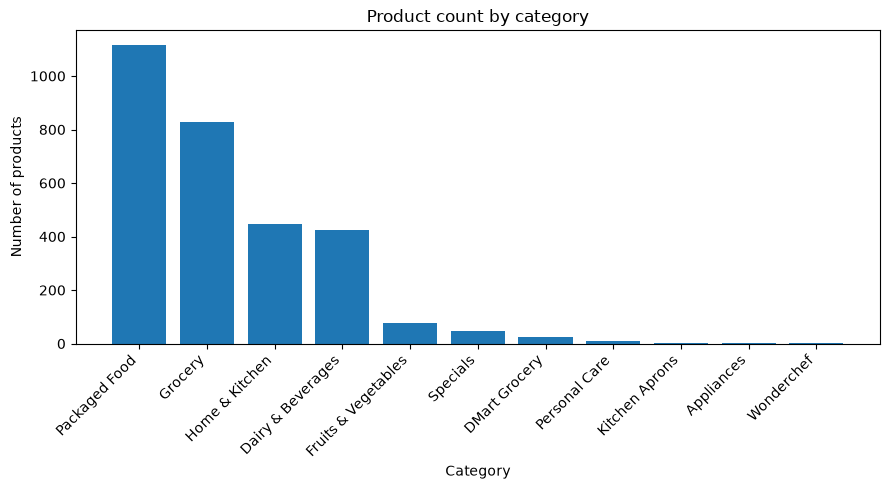

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
df = pd.read_csv("dmart.csv")
df = df.dropna(subset=["Name"])

counts = df["Category"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Number of products")
plt.title("Product count by category")
plt.tight_layout()
plt.show()

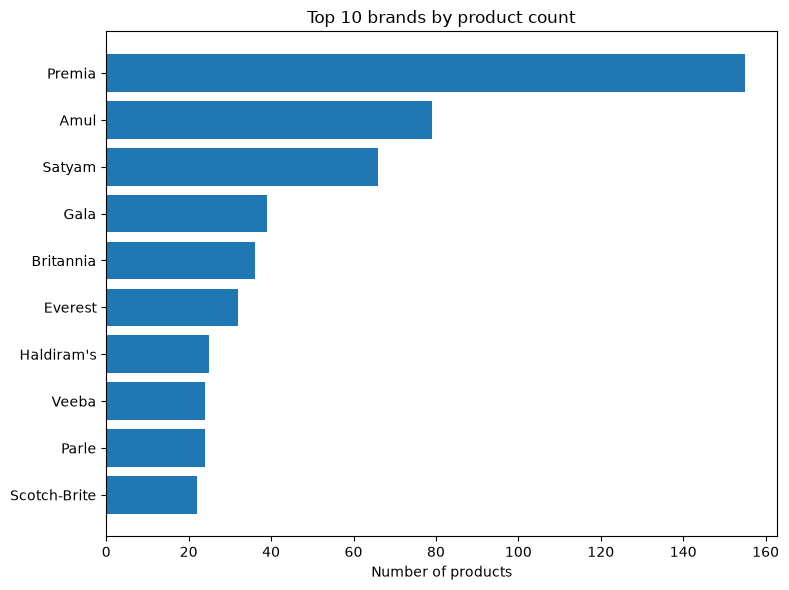

In [29]:
top_brands = df["Brand"].dropna().value_counts().head(10).sort_values()
 
plt.figure(figsize=(8, 6))
plt.barh(top_brands.index, top_brands.values)
plt.xlabel("Number of products")
plt.title("Top 10 brands by product count")
plt.tight_layout()
plt.show()

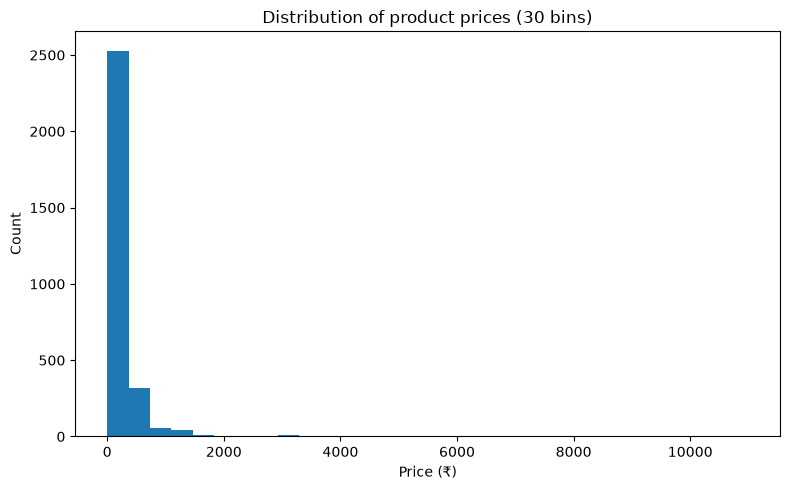

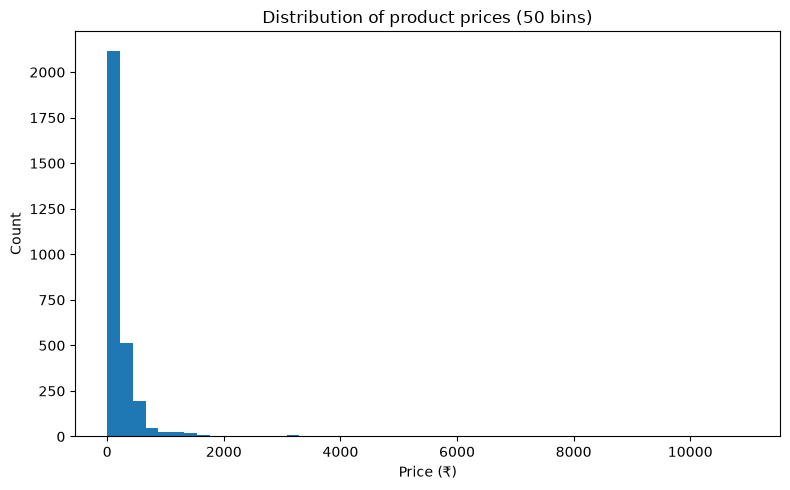

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=30)
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.title("Distribution of product prices (30 bins)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=50)
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.title("Distribution of product prices (50 bins)")
plt.tight_layout()


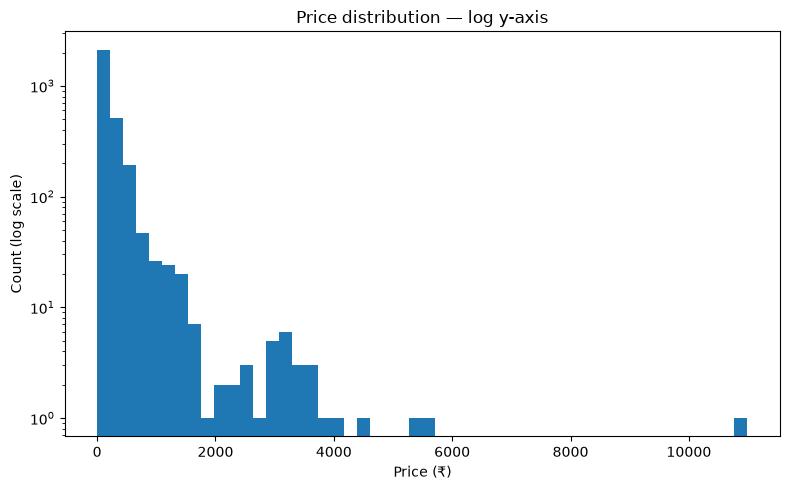

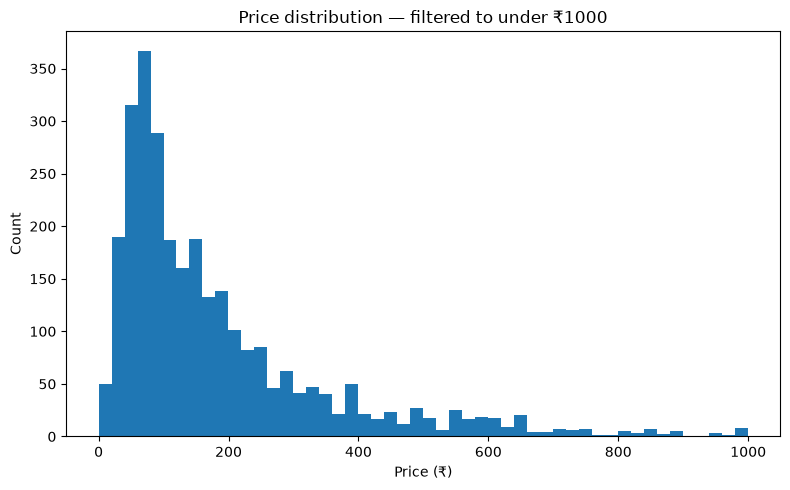

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=50)
plt.yscale("log")
plt.xlabel("Price (₹)")
plt.ylabel("Count (log scale)")
plt.title("Price distribution — log y-axis")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["Price"] < 1000, "Price"], bins=50)
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.title("Price distribution — filtered to under ₹1000")
plt.tight_layout()
plt.show()

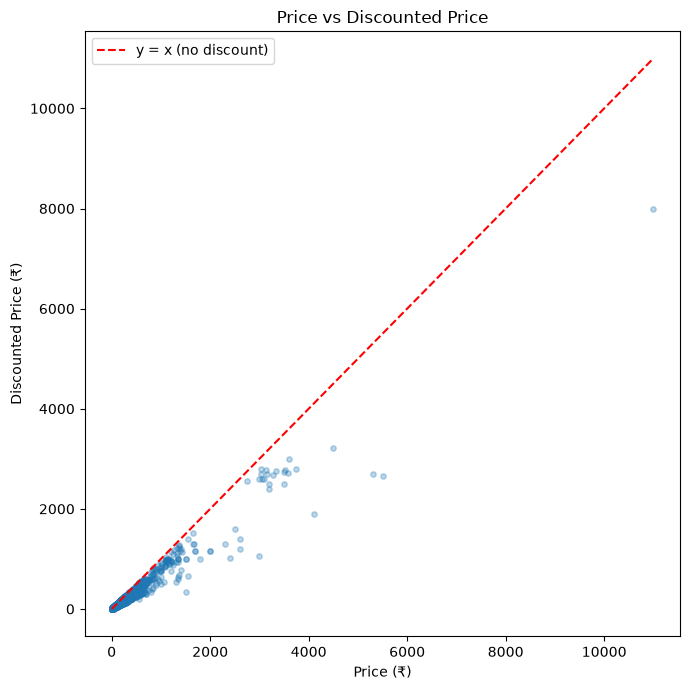

In [25]:
plt.figure(figsize=(7, 7))
plt.scatter(df["Price"], df["Discounted Price"], alpha=0.3, s=15)
max_val = df["Price"].max()
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="y = x (no discount)")
plt.xlabel("Price (₹)")
plt.ylabel("Discounted Price (₹)")
plt.title("Price vs Discounted Price")
plt.legend()
plt.tight_layout()

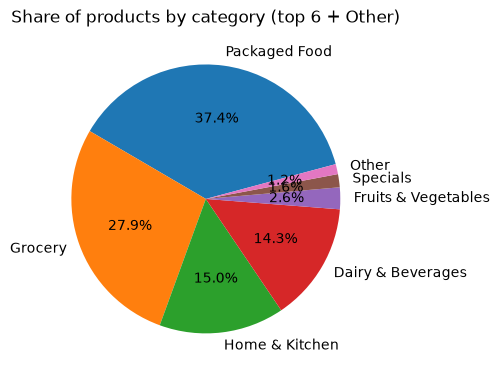

In [26]:
cat_counts = df["Category"].value_counts()
top6 = cat_counts.head(6)
other = pd.Series({"Other": cat_counts.iloc[6:].sum()})
pie_data = pd.concat([top6, other])

plt.figure(figsize=(5,5))
plt.xticks(rotation=45,ha='right')
plt.pie(pie_data.values, labels=pie_data.index, autopct="%1.1f%%", startangle=15)
plt.title("Share of products by category (top 6 + Other)")
plt.tight_layout()


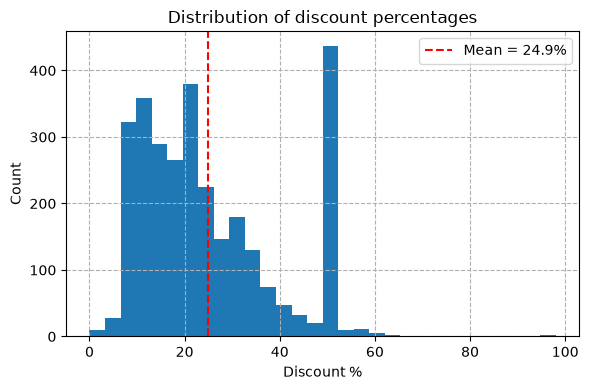

In [27]:
df["discount_pct"] = (df["Price"] - df["Discounted Price"]) / df["Price"] * 100
df["discount_pct"] = df["discount_pct"].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(6, 4))
plt.hist(df["discount_pct"].dropna(), bins=30)
plt.axvline(df["discount_pct"].mean(), color="red", linestyle="--",
            label=f"Mean = {df['discount_pct'].mean():.1f}%")
plt.xlabel("Discount %")
plt.ylabel("Count")
plt.title("Distribution of discount percentages")
plt.grid(True ,linestyle="--")
plt.legend()
plt.tight_layout()

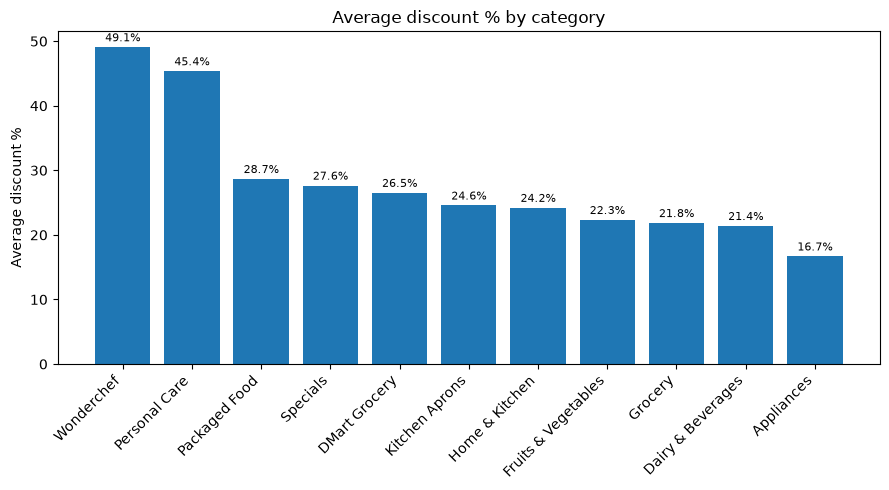

In [28]:
avg_disc = df.groupby("Category")["discount_pct"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_disc.index, avg_disc.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average discount %")
plt.title("Average discount % by category")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
              f"{height:.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

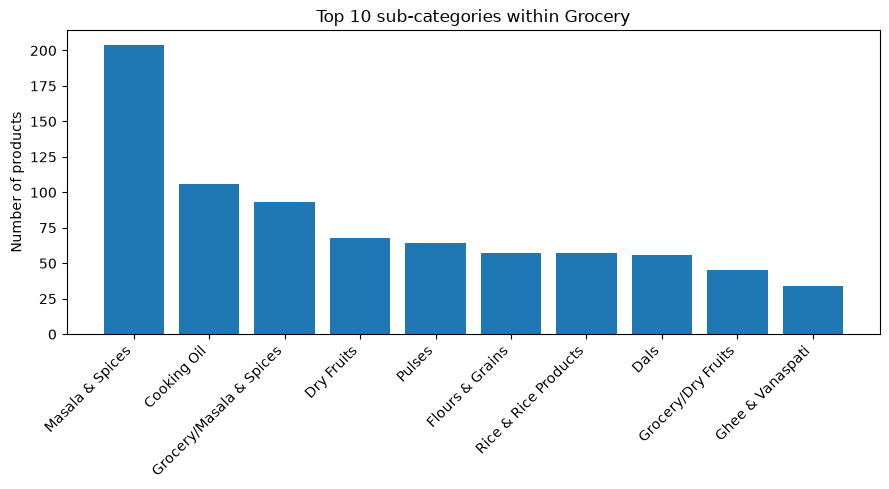

In [31]:
grocery = df[df["Category"] == "Grocery"]
top_subcats = grocery["Sub-Category"].value_counts().head(10)
 
plt.figure(figsize=(9, 5))
plt.bar(top_subcats.index, top_subcats.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of products")
plt.title("Top 10 sub-categories within Grocery")
plt.tight_layout()
plt.show()

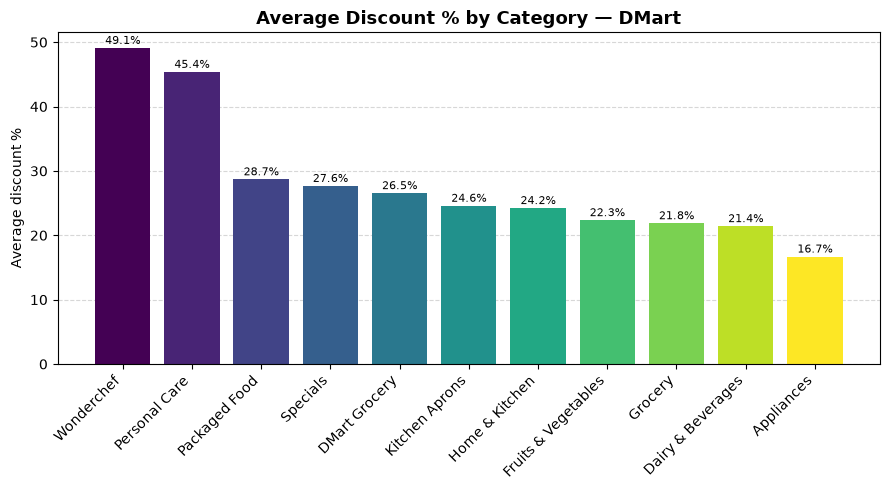

In [32]:
colors = plt.cm.viridis(np.linspace(0, 1, len(avg_disc)))
 
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_disc.index, avg_disc.values, color=colors)
ax.set_ylabel("Average discount %")
ax.set_title("Average Discount % by Category — DMart", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=45, ha="right")
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
 

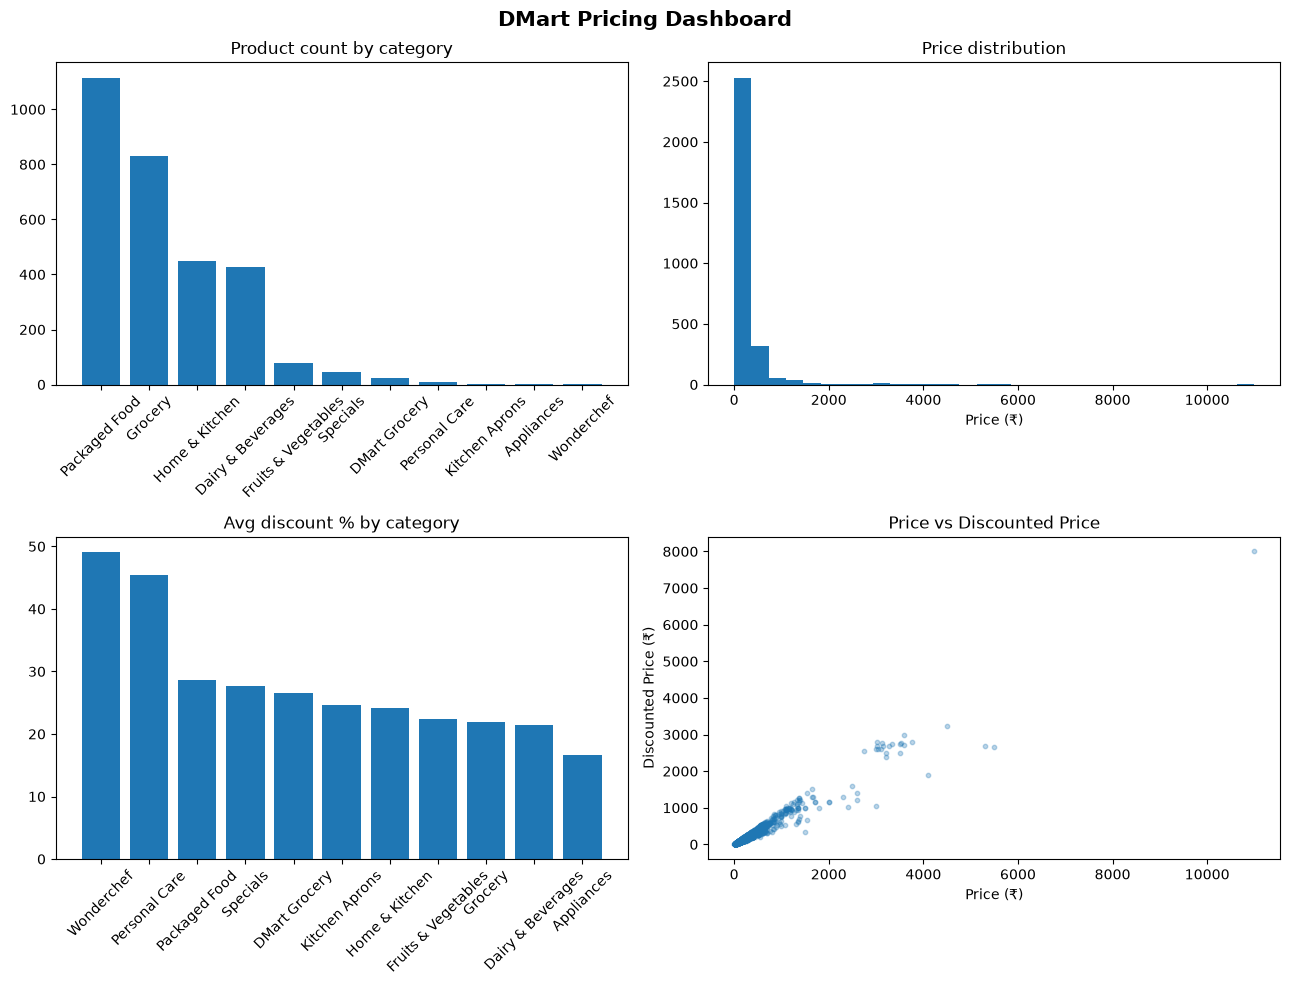

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
# Panel 1: category counts (Ex.1)
axes[0, 0].bar(counts.index, counts.values)
axes[0, 0].set_title("Product count by category")
axes[0, 0].tick_params(axis="x", rotation=45)
 
# Panel 2: price histogram (Ex.3)
axes[0, 1].hist(df["Price"], bins=30)
axes[0, 1].set_title("Price distribution")
axes[0, 1].set_xlabel("Price (₹)")
 
# Panel 3: avg discount % by category (Ex.7)
axes[1, 0].bar(avg_disc.index, avg_disc.values)
axes[1, 0].set_title("Avg discount % by category")
axes[1, 0].tick_params(axis="x", rotation=45)
 
# Panel 4: scatter price vs discounted price (Ex.5)
axes[1, 1].scatter(df["Price"], df["Discounted Price"], alpha=0.3, s=10)
axes[1, 1].set_title("Price vs Discounted Price")
axes[1, 1].set_xlabel("Price (₹)")
axes[1, 1].set_ylabel("Discounted Price (₹)")
 
fig.suptitle("DMart Pricing Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
 